# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
28,0.052606,-0.044642,-0.021295,-0.074527,-0.040096,-0.037639,-0.006584,-0.039493,-0.000612,-0.054925,131.0
310,-0.005515,-0.044642,0.064930,0.035644,-0.001569,0.014970,-0.013948,0.000729,-0.018114,0.032059,109.0
253,0.081666,-0.044642,0.033673,0.008101,0.052093,0.056619,-0.017629,0.034309,0.034866,0.069338,150.0
383,0.005383,0.050680,-0.028840,-0.009113,-0.031840,-0.028871,0.008142,-0.039493,-0.018114,0.007207,88.0
22,-0.085430,-0.044642,-0.004050,-0.009113,-0.002945,0.007767,0.022869,-0.039493,-0.061176,-0.013504,68.0
288,0.070769,0.050680,-0.016984,0.021872,0.043837,0.056305,0.037595,-0.002592,-0.070209,-0.017646,80.0
52,-0.052738,-0.044642,-0.009439,-0.005670,0.039710,0.044719,0.026550,-0.002592,-0.018114,-0.013504,59.0
43,0.019913,-0.044642,-0.023451,-0.071085,0.020446,-0.010082,0.118591,-0.076395,-0.042571,0.073480,92.0
240,0.048974,0.050680,0.074630,0.066629,-0.009825,-0.002253,-0.043401,0.034309,0.033654,0.019633,275.0
286,-0.038207,-0.044642,-0.054707,-0.077970,-0.033216,-0.086490,0.140681,-0.076395,-0.019198,-0.005220,60.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
# Contar valores faltantes por columna
missing_counts = data.isna().sum()
missing_counts

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
# Imputación simple con la media en la columna 'bmi'
mean_imputer = SimpleImputer(strategy='mean')
data['bmi'] = mean_imputer.fit_transform(data[['bmi']])

# Verificar que no queden valores faltantes en 'bmi'
data['bmi'].isna().sum()

np.int64(0)

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
# Recrear el conjunto con el mismo patrón de valores faltantes para comparar
data_knn = diabetes.data.copy()
data_knn['target'] = diabetes.target
np.random.seed(42)
data_knn.loc[data_knn.sample(frac=0.1).index, 'bmi'] = np.nan
data_knn.loc[data_knn.sample(frac=0.1).index, 'bp'] = np.nan

# Imputar con KNN usando todas las columnas numéricas excepto target
cols = data_knn.columns.drop('target')
knn_imputer = KNNImputer(n_neighbors=5)
data_knn[cols] = knn_imputer.fit_transform(data_knn[cols])

# Comparar estadísticas de la columna bmi entre imputación simple y KNN
comparison = pd.DataFrame({
    'simple_mean_imputation': [data['bmi'].mean(), data['bmi'].std()],
    'knn_imputation': [data_knn['bmi'].mean(), data_knn['bmi'].std()]
}, index=['mean', 'std'])
comparison

,simple_mean_imputation,knn_imputation
mean,-0.000205,0.000351
std,0.044583,0.045381


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

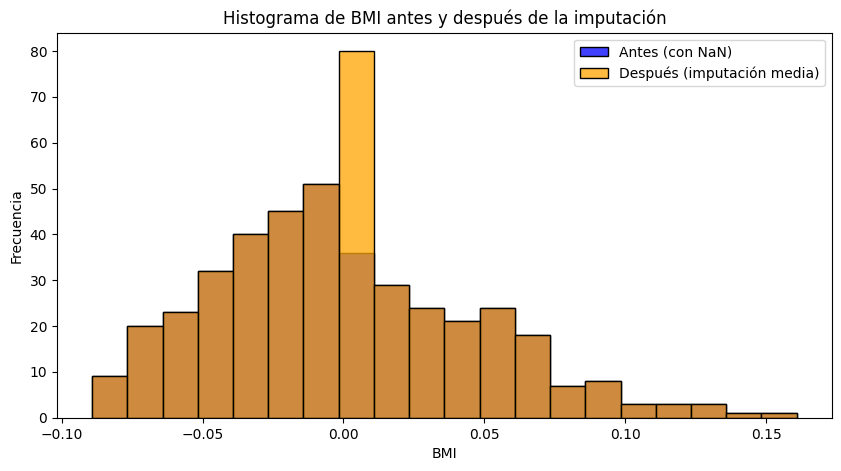

In [8]:
# Generar histograma comparando BMI antes y después de la imputación simple
original = diabetes.data.copy()
np.random.seed(42)
original.loc[original.sample(frac=0.1).index, 'bmi'] = np.nan

imputed = original.copy()
imputed['bmi'] = mean_imputer.fit_transform(imputed[['bmi']])

plt.figure(figsize=(10, 5))
sns.histplot(original['bmi'], color='blue', label='Antes (con NaN)', kde=False, bins=20)
sns.histplot(imputed['bmi'], color='orange', label='Después (imputación media)', kde=False, bins=20)
plt.legend()
plt.title('Histograma de BMI antes y después de la imputación')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()